In [33]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import cv2

In [34]:
img = cv2.imread('./image_ds/maria_sharapova/sharapova-hits-the-practice-courts-and-met-ball-kids.jpg')
img.shape

(555, 700, 3)

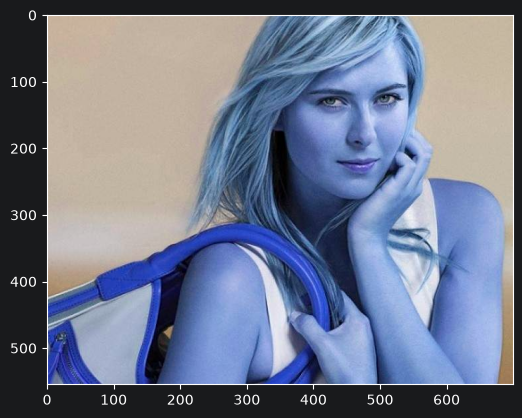

In [35]:
plt.imshow(img)

doing this removes the RGB (3rd dimension)

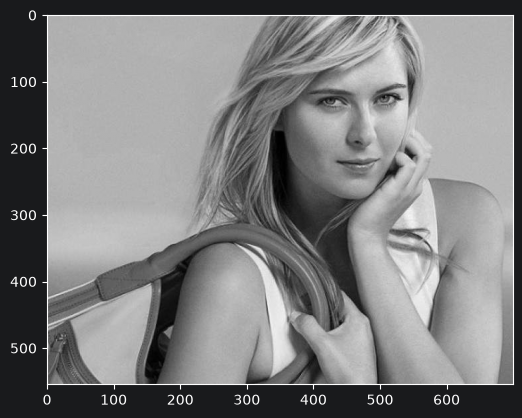

In [36]:
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray,cmap='gray')

haar features in open cv for facial recognition

In [37]:
face_cascade = cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_frontalface_default.xml')
eye_cascade = cv2.CascadeClassifier('./opencv/haarcascades/haarcascade_eye.xml')
faces = face_cascade.detectMultiScale(gray, 1.3, 5)
faces

array([[352,  38, 233, 233]], dtype=int32)

In [38]:
[x, y, w, h] = faces[0]
x,y,w,h

(np.int32(352), np.int32(38), np.int32(233), np.int32(233))

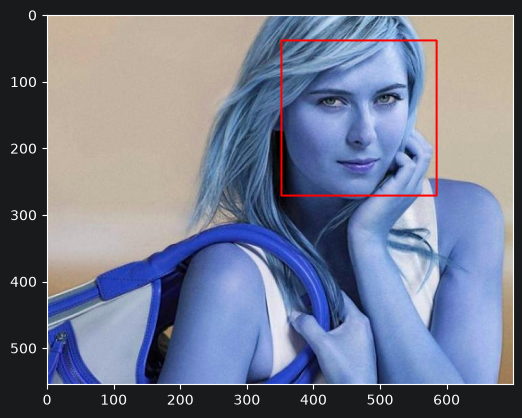

In [39]:
face_img = cv2.rectangle(img,(x,y),(x+w,y+h),(255,0,0),2)
plt.imshow(face_img)

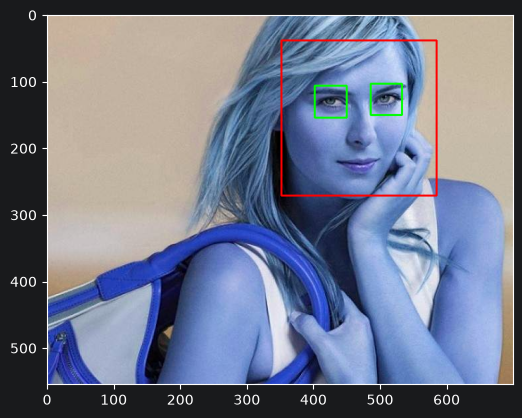

In [43]:
cv2. destroyAllWindows()
for (x,y, w,h) in faces:
    face_img = cv2.rectangle(img, (x,y), (x+w,y+h), (255, 0,0),2)
    roi_gray = gray[y:y+h, x:x+w]
    roi_color = face_img[y:y+h, x:x+w]
    eyes = eye_cascade.detectMultiScale(roi_gray)
    for (ex, ey, ew, eh) in eyes:
        cv2.rectangle(roi_color, (ex, ey), (ex+ew, ey+eh), (0,255,0), 2)
plt.figure()
plt.imshow(face_img, cmap='gray')
plt.show()

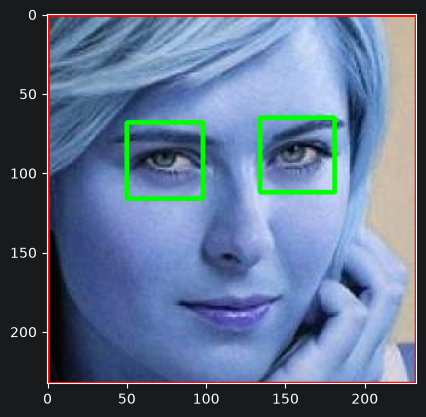

In [44]:
plt.imshow(roi_color, cmap='gray')

In [45]:
def get_cropped_image_if_2_eyes (image_path) :
    img = cv2. imread (image_path)
    gray = cv2.cvtColor(img, cv2. COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray, 1.3, 5)
    for (x,y, w,h) in faces:
        roi_gray = gray[y:y+h, x:x+w]
        roi_color = img[y:y+h, x:x+w]
        eyes = eye_cascade.detectMultiScale(roi_gray)
        if len(eyes) >= 2:
            return roi_color